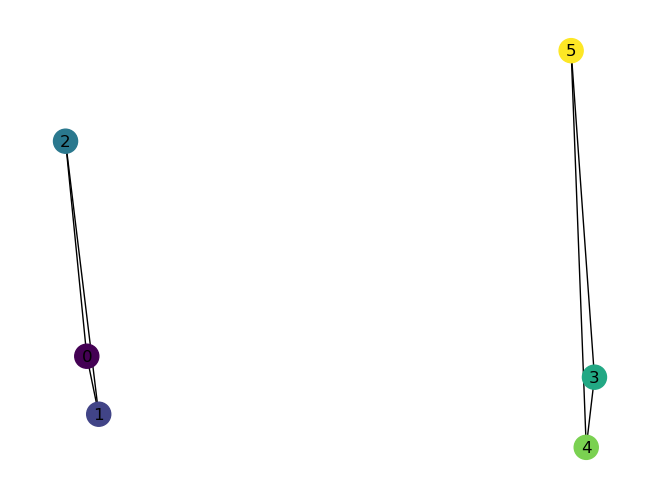

In [1]:
import networkx as nx
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def fastRP(G, dim=8, k=4):
    A = nx.to_numpy_array(G)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(1) + 1e-8))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    Z = np.zeros((A.shape[0], dim))
    X = np.random.randn(A.shape[0], dim)
    for i in range(1, k+1):
        X = A_hat @ X
        Z += X
    return Z

# Example: two triangles
G = nx.disjoint_union(nx.complete_graph(3), nx.complete_graph(3))
emb = fastRP(G, dim=8)
pca = PCA(n_components=2).fit_transform(emb)

nx.draw(G, pos={i: pca[i] for i in range(len(G))}, with_labels=True, node_color=range(len(G)))
plt.show()


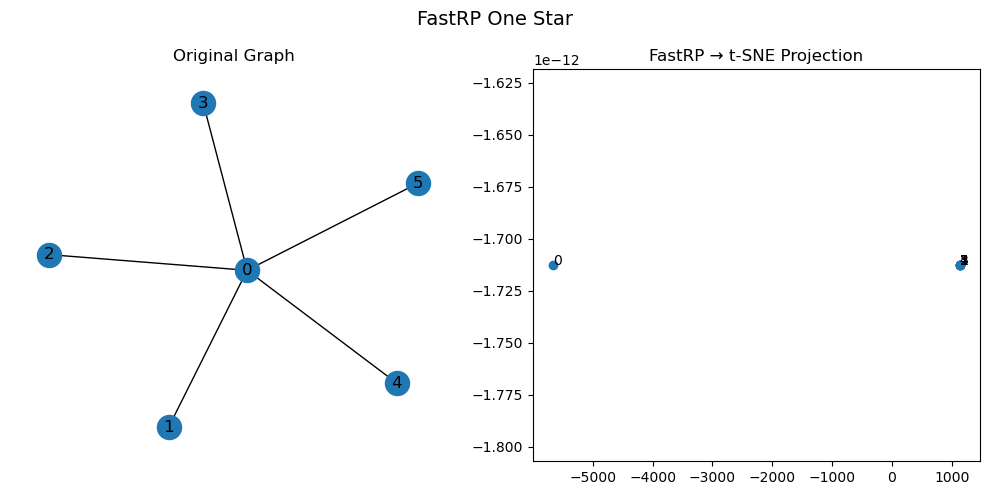

Saved: /mnt/data/fastrp_one_star.png


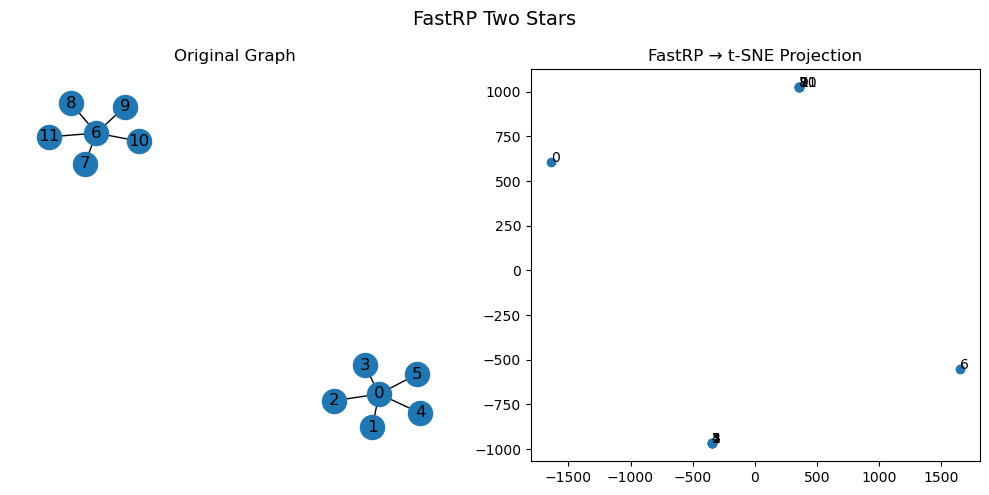

Saved: /mnt/data/fastrp_two_stars.png


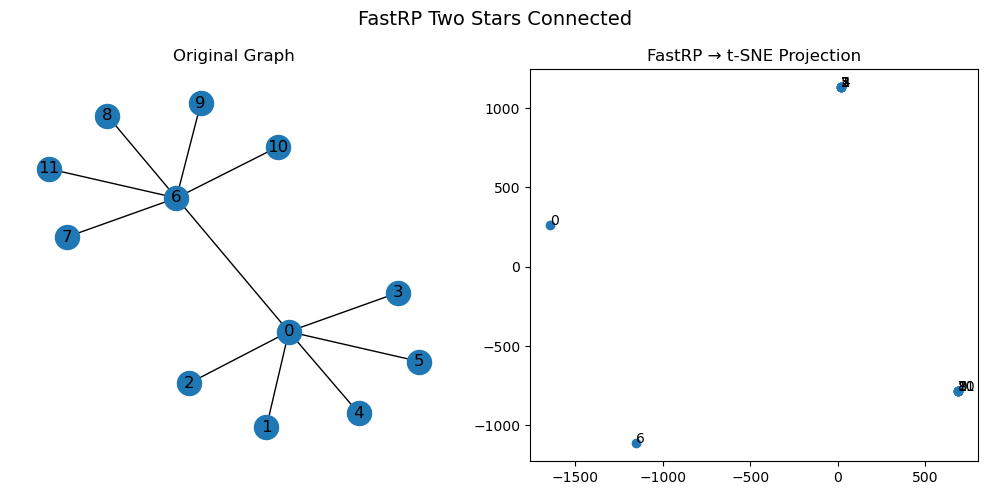

Saved: /mnt/data/fastrp_two_stars_connected.png
✅ All side-by-side FastRP figures saved under /mnt/data/


In [25]:
# -*- coding: utf-8 -*-
"""
FastRP toy examples (side-by-side visualization)

For each example:
  - Compute FastRP embeddings.
  - Run t-SNE on embeddings.
  - Plot side-by-side:
      left  = original graph (spring layout)
      right = t-SNE projection (with node indices)
  - Save to /mnt/data/fastrp_<example>.png
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------- Core utilities ----------
def fastRP_embedding_single(G: nx.Graph, dim: int = 16, k: int = 4, seed: int = 0):
    """Simple FastRP-style embedding."""
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes)
    deg = A.sum(1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt

    R = rng.standard_normal((A.shape[0], dim))
    Z = np.zeros_like(R)
    X = R.copy()
    for _ in range(k):
        X = A_hat @ X
        Z += X
    norms = np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12
    Z = Z / norms
    return nodes, Z


def fastRP_embedding(G: nx.Graph, dim: int = 128, k: int = 4, seed: int = 0):
    """FastRP-style embedding."""
    Z_avg = None
    for s in range(seed, seed+10000):
        nodes, Z = fastRP_embedding_single(G, dim, k, s)
        if Z_avg is None:
            Z_avg = Z
        else:
            Z_avg += Z
    Z_avg /= 10000
    return nodes, Z_avg

def tsne_2d(Z: np.ndarray, seed: int = 0):
    perplexity = max(5, min(20, Z.shape[0] - 1))
    tsne = TSNE(
        n_components=2, random_state=seed,
        perplexity=perplexity, init="pca", learning_rate="auto"
    )
    return tsne.fit_transform(Z)


def plot_side_by_side(G, nodes, coords_2d, title, filename, seed=0):
    """Side-by-side: Graph (left) vs FastRP t-SNE (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.suptitle(title, fontsize=14, y=0.98)

    # --- Left: Graph ---
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos=pos, with_labels=True, ax=axes[0])
    axes[0].set_title("Original Graph")

    # --- Right: t-SNE ---
    x, y = coords_2d[:, 0], coords_2d[:, 1]
    axes[1].scatter(x, y)
    for i, n in enumerate(nodes):
        axes[1].text(x[i], y[i], str(n))
    axes[1].set_title("FastRP → t-SNE Projection")
    #axes[1].axis("off")

    plt.tight_layout()
    # plt.savefig(filename, dpi=160, bbox_inches="tight")
    # plt.close(fig)
    plt.show()


def embed_and_plot(G, basename, dim=16, k=4, seed=0):
    nodes, Z = fastRP_embedding(G, dim=dim, k=k, seed=seed)
    coords = tsne_2d(Z, seed=seed)
    filename = f"/mnt/data/{basename.lower().replace(' ', '_')}.png"
    plot_side_by_side(G, nodes, coords, basename, filename, seed=seed)
    print(f"Saved: {filename}")


# ---------- Examples ----------
def example_one_star():
    S = nx.star_graph(5)
    embed_and_plot(S, "FastRP One Star")

def example_two_stars():
    S1 = nx.star_graph(5)
    S2 = nx.relabel_nodes(nx.star_graph(5), lambda x: x + 6)
    G = nx.disjoint_union(S1, S2)
    embed_and_plot(G, "FastRP Two Stars")

def example_two_stars_connected():
    S1 = nx.star_graph(5)
    S2 = nx.relabel_nodes(nx.star_graph(5), lambda x: x + 6)
    G = nx.disjoint_union(S1, S2)
    G.add_edge(0, 6)
    embed_and_plot(G, "FastRP Two Stars Connected")


def example_two_paths():
    P1 = nx.path_graph(5)
    P2 = nx.relabel_nodes(nx.path_graph(5), lambda x: x + 5)
    G = nx.disjoint_union(P1, P2)
    embed_and_plot(G, "FastRP Two Paths")


def example_two_communities_bridge():
    C1 = nx.complete_graph(5)
    C2 = nx.relabel_nodes(nx.complete_graph(5), lambda x: x + 5)
    G = nx.disjoint_union(C1, C2)
    G.add_edge(4, 5)
    embed_and_plot(G, "FastRP Two Communities Bridge")


def example_bipartite():
    B = nx.Graph()
    users = [f"u{i}" for i in range(4)]
    items = [f"i{j}" for j in range(3)]
    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(items, bipartite=1)
    edges = [
        ("u0", "i0"), ("u0", "i1"),
        ("u1", "i0"), ("u1", "i2"),
        ("u2", "i1"),
        ("u3", "i1"), ("u3", "i2"),
    ]
    B.add_edges_from(edges)
    embed_and_plot(B, "FastRP Bipartite Users Items")


def example_tree():
    T = nx.balanced_tree(r=2, h=3)
    embed_and_plot(T, "FastRP Tree")


def example_triangle_vs_chain():
    tri = nx.complete_graph(3)
    path = nx.relabel_nodes(nx.path_graph(4), lambda x: x + 3)
    G = nx.disjoint_union(tri, path)
    embed_and_plot(G, "FastRP Triangle vs Chain")


def example_bridge_vs_cluster():
    C = nx.complete_graph(6)
    C.add_edge(6, 7)
    C.add_edge(7, 0)
    embed_and_plot(C, "FastRP Bridge vs Cluster")


# ---------- Run all ----------
example_one_star()
example_two_stars()
example_two_stars_connected()
# example_two_paths()
# example_two_communities_bridge()
# example_bipartite()
# example_tree()
# example_triangle_vs_chain()
# example_bridge_vs_cluster()

print("✅ All side-by-side FastRP figures saved under /mnt/data/")
